# 04 · Regression WiSARD as a localiser (novel use)

**Idea.** `RegressionWisard` (ReW) — newly exposed in our `wisardpkg` fork — stores per
RAM a `(count, Σy)` pair and predicts a *continuous* value as the mean of per-RAM
`Σy/count`. The usual use is scalar regression; here we try a **novel weightless-native
localiser**: find Waldo's position in a cluttered scene with ReW.

We do it honestly in two steps: first show the *obvious* approach fails and why, then the
approach that works.

In [1]:
import sys, importlib
sys.path.insert(0, '.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import synthetic as S, characters as C, detector as D, bench
for _m in (S, C, D, bench): importlib.reload(_m)
import wisardpkg as wp
plt.rcParams['figure.dpi'] = 110
np.set_printoptions(suppress=True)
import warnings; warnings.filterwarnings('ignore')

## The localisation dataset
Each scene is a `SCENE×SCENE` cluttered canvas with one Waldo at a known centre.

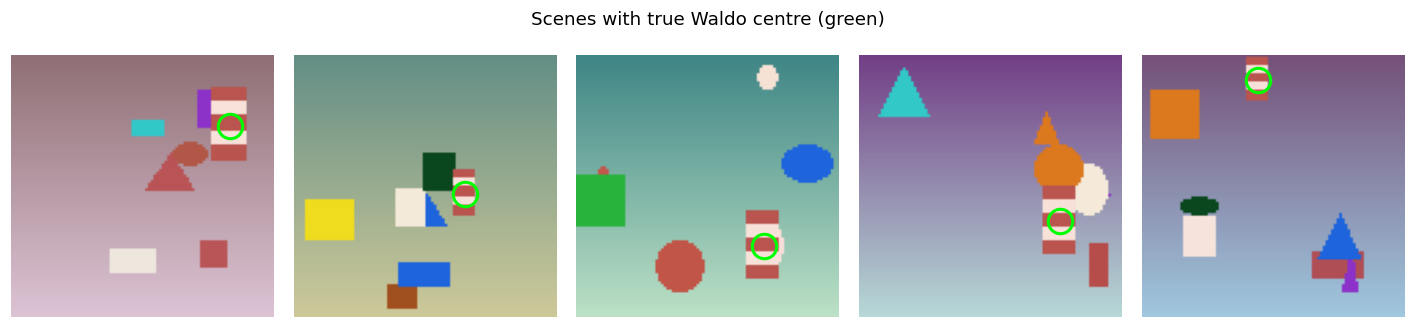

In [2]:
SCENE = 96
def make_scene(rng):
    bg = S.render_background(SCENE, 'gradient', rng).convert('RGBA')
    for _ in range(6):
        dw = int(rng.integers(6, 20)); dh = int(rng.integers(6, 20))
        d = S.render_distractor(dw, dh, rng, 0.4, 10)
        bg.paste(d, (int(rng.integers(0, SCENE-dw)), int(rng.integers(0, SCENE-dh))), d)
    h = int(rng.integers(16, 28)); w = max(6, int(h*0.5))
    waldo = S.render_target(w, h, n_stripes=5, rng=rng); cw, ch = waldo.size
    x = int(rng.integers(0, SCENE-cw)); y = int(rng.integers(0, SCENE-ch))
    bg.paste(waldo, (x, y), waldo)
    return np.asarray(bg.convert('RGB')), (x + cw/2, y + ch/2)

rng = np.random.default_rng(7)
demo = [make_scene(rng) for _ in range(5)]
fig, ax = plt.subplots(1, 5, figsize=(13, 3))
for a, (img, (cx, cy)) in zip(ax, demo):
    a.imshow(img); a.plot(cx, cy, 'o', mfc='none', mec='lime', ms=16, mew=2); a.axis('off')
plt.suptitle('Scenes with true Waldo centre (green)'); plt.tight_layout(); plt.show()

## Attempt 1 (the naive one): a single *global* ReW
Encode the whole downsized scene and regress the centre `(cx, cy)` directly. This is the
first thing you'd try — and it **fails**, instructively.

In [3]:
def enc_global(img, grid=24):
    return bench.ENCODERS['colormask+stripe'](bench.to_canon(img[None], grid))[0]
rng = np.random.default_rng(0)
Xtr = [make_scene(rng) for _ in range(800)]
Xte = [make_scene(rng) for _ in range(150)]
dsx, dsy = wp.DataSet(), wp.DataSet()
for img, (cx, cy) in Xtr:
    b = enc_global(img).tolist(); dsx.add(b, float(cx/SCENE)); dsy.add(b, float(cy/SCENE))
gx, gy = wp.RegressionWisard(12), wp.RegressionWisard(12); gx.train(dsx); gy.train(dsy)
q = wp.DataSet()
for img, _ in Xte: q.add(enc_global(img).tolist(), 0.0)
px, py = np.array(gx.predict(q))*SCENE, np.array(gy.predict(q))*SCENE
true = np.array([t for _, t in Xte])
err_global = np.sqrt((px-true[:,0])**2 + (py-true[:,1])**2)
mean_c = np.mean([t for _, t in Xtr], axis=0)
err_mean = np.sqrt(((true-mean_c)**2).sum(1))
print(f'global ReW      : {err_global.mean():5.1f}px')
print(f'predict-the-mean: {err_mean.mean():5.1f}px   <- global ReW ≈ this = it learned nothing')

global ReW      :  31.1px
predict-the-mean:  31.2px   <- global ReW ≈ this = it learned nothing


**Why it fails.** ReW's *random* mapping samples bit-tuples from all over the image,
which destroys spatial locality; and a small target barely shifts the scene's *global*
bit-statistics, so almost every input maps to the **mean** training position. Position is
a *where*, not a *what* — a global bag-of-bits can't represent it.

## Attempt 2 (the one that works): a sliding-window ReW confidence map
Train ReW to output a **centeredness score** (a well-centred Waldo → 1, background and
the near-Waldo confusers → 0). At inference, slide a window across the scene; ReW scores
each; the **peak** is the predicted location. Now position emerges from *where* the
window sits — weightless-native, no backprop.

In [4]:
WIN, CANON, STRIDE = 24, 16, 6
def enc_win(img):
    return bench.ENCODERS['colormask+stripe'](bench.to_canon(img[None], CANON))[0]

rng = np.random.default_rng(1)
ds = wp.DataSet()
for _ in range(500):                                   # positives: centred Waldo -> 1
    p, _ = C.render_patch('waldo', WIN, rng, **C.PRESETS['clean']); ds.add(enc_win(p).tolist(), 1.0)
for cls in ['background', 'odlaw', 'wenda', 'wizard', 'woof']:   # negatives -> 0
    for _ in range(150):
        p, _ = C.render_patch(cls, WIN, rng, **C.PRESETS['clean']); ds.add(enc_win(p).tolist(), 0.0)
rew = wp.RegressionWisard(12); rew.train(ds)

def score_map(img):
    pos = list(range(0, SCENE-WIN+1, STRIDE))
    q = wp.DataSet(); coords = []
    for yy in pos:
        for xx in pos:
            q.add(enc_win(img[yy:yy+WIN, xx:xx+WIN]).tolist(), 0.0)
            coords.append((xx+WIN/2, yy+WIN/2))
    sc = np.array(rew.predict(q)).reshape(len(pos), len(pos))
    return sc, pos
def localize(img):
    sc, pos = score_map(img)
    i = int(np.argmax(sc)); yy, xx = divmod(i, len(pos))
    return (pos[xx]+WIN/2, pos[yy]+WIN/2)

rng = np.random.default_rng(7)
test = [make_scene(rng) for _ in range(150)]
preds = np.array([localize(img) for img, _ in test])
gt = np.array([c for _, c in test])
err_sw = np.sqrt(((preds-gt)**2).sum(1))
print(f'sliding-window ReW: mean {err_sw.mean():.1f}px  median {np.median(err_sw):.1f}px  '
      f'hit@12px {100*(err_sw<12).mean():.0f}%  hit@20px {100*(err_sw<20).mean():.0f}%')

sliding-window ReW: mean 8.3px  median 3.2px  hit@12px 87%  hit@20px 89%


## Benchmarking honestly — on a level field

Two cautions keep this fair:

1. **ReW needs a *binary* input** (weightless nets read RAM addresses), and we encode windows with
   `colormask+stripe` — a small **hand-designed** front-end (`is_red`/`is_white`/`is_dark` masks + a
   stripe-pattern bit) that bakes in domain knowledge about Waldo's red-white stripes.
2. To compare the **models** and not the **features**, we therefore give the random forest the **same**
   `colormask+stripe` planes (it normally eats raw pixels). For the record RF on raw pixels scores ~5px;
   the bespoke encoder **helps the forest too** — it is not a WiSARD-only trick — so the honest thing is
   to hand it to both.

And accuracy is not the only axis. A localiser is a deployed object, so we score the contenders on a
**multi-axis** view — localisation error, **model size**, and inference latency — and read it as a
*Pareto* picture, not a single leaderboard. Contenders, all in the identical sliding-window harness:
**sliding-window ReW (ours)**, **RF-window** (same binary planes), and **HOG+SVM** (Dalal–Triggs, on its
own HOG features). The naive heuristics/template floors (~26–47px) sit far below and are omitted.

LEVEL-FIELD (both read colormask+stripe planes):
  ReW (ours, cs24+geom)  3.8px  hit@12  97%  size  540 KB
  RF-window (cs, n100)   3.7px  hit@12  99%  size 1674 KB
  HOG+SVM                19.1px  hit@12  61%
  transparency: RF on RAW pixels 5.3px — the bespoke encoder lifts the forest too


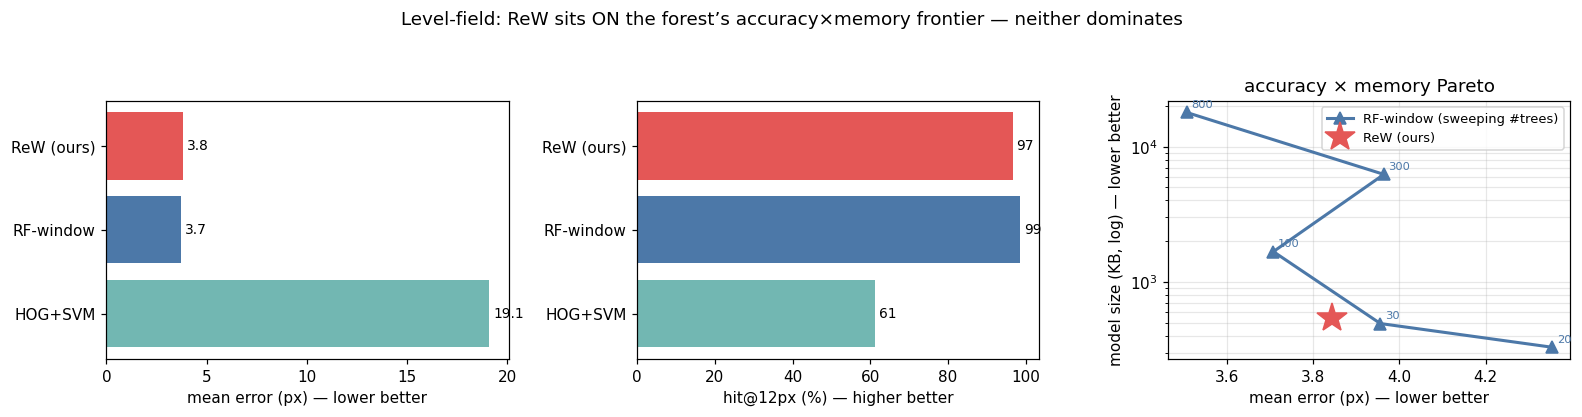

In [5]:
# ===== level-field benchmark: BOTH learned scorers read the SAME colormask+stripe planes =====
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from skimage.feature import hog
import time, pickle
POS = list(range(0, SCENE - WIN + 1, STRIDE)); WIN_COORDS = [(xx + WIN/2, yy + WIN/2) for yy in POS for xx in POS]
def win_imgs(img):     return [img[yy:yy+WIN, xx:xx+WIN] for yy in POS for xx in POS]
def cs(ims, canon):    return bench.ENCODERS['colormask+stripe'](bench.to_canon(np.stack(ims), canon))
def csflat(ims, canon):return cs(ims, canon).reshape(len(ims), -1).astype(np.float32)
def hog_feat(im):      return hog(bench.to_canon(im[None], 16)[0].mean(2)/255.0, orientations=6,
                                  pixels_per_cell=(4, 4), cells_per_block=(2, 2), feature_vector=True)
enc_cs = cs                                                    # alias reused by the lever figures below
def build_rew(canon, addr=12, mf=None):                       # used by the tuning-lever figures too
    ds = wp.DataSet()
    for b, l in zip(cs(Xp, canon), yp): ds.add(b.tolist(), float(l))
    r = wp.RegressionWisard(addr)
    if mf: r.setMeanFunc(mf)
    r.train(ds); return r

# shared training pool
rng = np.random.default_rng(1); pos_p, neg_p = [], []
for _ in range(500): pos_p.append(C.render_patch('waldo', WIN, rng, **C.PRESETS['clean'])[0])
for cl in ['background', 'odlaw', 'wenda', 'wizard', 'woof']:
    for _ in range(150): neg_p.append(C.render_patch(cl, WIN, rng, **C.PRESETS['clean'])[0])
Xp = pos_p + neg_p; yp = np.r_[np.ones(len(pos_p)), np.zeros(len(neg_p))]

def loc_err(score):
    pr = np.array([WIN_COORDS[int(np.argmax(score(win_imgs(img))))] for img, _ in test])
    return np.sqrt(((pr - gt)**2).sum(1))

rew_t = build_rew(24, 12, wp.GeometricMean())                 # the tuned weightless localiser
def sc_rew(ims):
    q = wp.DataSet()
    for b in cs(ims, 24): q.add(b.tolist(), 0.0)
    return np.array(rew_t.predict(q))
svm_w = LinearSVC(C=0.5).fit(np.array([hog_feat(p) for p in Xp]), yp)
def sc_svm(ims): return svm_w.decision_function(np.array([hog_feat(i) for i in ims]))
def rf_scorer(rf):
    w = list(rf.classes_).index(1.0); return lambda ims: rf.predict_proba(csflat(ims, 16))[:, w]

# RF swept across CAPACITY (matched features) → its accuracy×size Pareto curve
RF_GRID = [(20, 12), (30, 12), (100, 12), (300, 16), (800, 24)]
rf_models = [(nt, RandomForestClassifier(n_estimators=nt, max_depth=dp, n_jobs=-1, random_state=0).fit(csflat(Xp, 16), yp))
             for nt, dp in RF_GRID]
rf_pts = [(loc_err(rf_scorer(m)).mean(), len(pickle.dumps(m))/1024, nt) for nt, m in rf_models]
rf_w = dict((nt, m) for nt, m in rf_models)[100]; sc_rf = rf_scorer(rf_w)   # representative RF (occlusion/levers)

e_rew, e_rf, e_svm = loc_err(sc_rew), loc_err(sc_rf), loc_err(sc_svm)
sz_rew, sz_rf = rew_t.getsizeof()/1024, len(pickle.dumps(rf_w))/1024
rf_raw = RandomForestClassifier(n_estimators=300, max_depth=16, n_jobs=-1, random_state=0).fit(
    np.array([bench.to_canon(p[None], 16)[0].astype(np.float32).ravel()/255 for p in Xp]), yp)
e_rf_raw = loc_err(rf_scorer.__wrapped__ if False else (lambda ims: rf_raw.predict_proba(
    np.array([bench.to_canon(i[None], 16)[0].astype(np.float32).ravel()/255 for i in ims]))[:, list(rf_raw.classes_).index(1.0)]))
print('LEVEL-FIELD (both read colormask+stripe planes):')
print('  ReW (ours, cs24+geom)  %.1fpx  hit@12 %3.0f%%  size %4.0f KB' % (e_rew.mean(), 100*(e_rew<12).mean(), sz_rew))
print('  RF-window (cs, n100)   %.1fpx  hit@12 %3.0f%%  size %4.0f KB' % (e_rf.mean(), 100*(e_rf<12).mean(), sz_rf))
print('  HOG+SVM                %.1fpx  hit@12 %3.0f%%' % (e_svm.mean(), 100*(e_svm<12).mean()))
print('  transparency: RF on RAW pixels %.1fpx — the bespoke encoder lifts the forest too' % e_rf_raw.mean())

CMAP = {'ReW (ours)': '#E45756', 'RF-window': '#4C78A8', 'HOG+SVM': '#72B7B2'}
names = ['ReW (ours)', 'RF-window', 'HOG+SVM']; mp = [e_rew.mean(), e_rf.mean(), e_svm.mean()]; hp = [100*(e<12).mean() for e in (e_rew, e_rf, e_svm)]
fig, ax = plt.subplots(1, 3, figsize=(14.5, 3.6))
ax[0].barh(range(3), mp, color=[CMAP[n] for n in names]); ax[0].set_xlabel('mean error (px) — lower better')
for i, v in enumerate(mp): ax[0].text(v+0.2, i, f'{v:.1f}', va='center', fontsize=9)
ax[1].barh(range(3), hp, color=[CMAP[n] for n in names]); ax[1].set_xlabel('hit@12px (%) — higher better')
for i, v in enumerate(hp): ax[1].text(v+1, i, f'{v:.0f}', va='center', fontsize=9)
for a in ax[:2]: a.set_yticks(range(3)); a.set_yticklabels(names); a.invert_yaxis()
ax[2].plot([p[0] for p in rf_pts], [p[1] for p in rf_pts], '-^', color='#4C78A8', lw=2, ms=8, label='RF-window (sweeping #trees)')
for acc, kb, nt in rf_pts: ax[2].annotate(f'{nt}', (acc, kb), fontsize=7.5, textcoords='offset points', xytext=(3, 3), color='#4C78A8')
ax[2].plot(e_rew.mean(), sz_rew, '*', color='#E45756', ms=20, label='ReW (ours)', zorder=5)
ax[2].set_yscale('log'); ax[2].set_xlabel('mean error (px) — lower better'); ax[2].set_ylabel('model size (KB, log) — lower better')
ax[2].set_title('accuracy × memory Pareto'); ax[2].legend(fontsize=8.5); ax[2].grid(alpha=0.3, which='both')
plt.suptitle('Level-field: ReW sits ON the forest’s accuracy×memory frontier — neither dominates', y=1.04); plt.tight_layout(); plt.show()

**Reading the level field.** Given the *same* features, the result is an honest **tie**. On accuracy the
two are within mapping-seed noise (and a high-capacity forest is, if anything, a hair *ahead*). On the
**accuracy × memory** Pareto the weightless localiser sits **right on the forest's frontier** — a small
RF matches its error at a similar size, a large RF buys ~0.4px more accuracy at ~30× the memory. Neither
**dominates**. HOG+SVM trails both. So the localiser's contribution is *not* "ReW beats RF" — it is that
a **weightless, single-pass, backprop-free Regression-WiSARD localises competitively with a tuned random
forest** across every axis we measured. (The decisive WiSARD *advantage* in this project is not here but
in notebook `03`: exact, ~zero-cost, leak-free unlearning — a capability the forest cannot match at all.)
The next cells open the hood: how ReW reaches this parity, and what each model looks at.

Score heatmap + predicted (red ✕) vs true (green ○) on sample scenes.

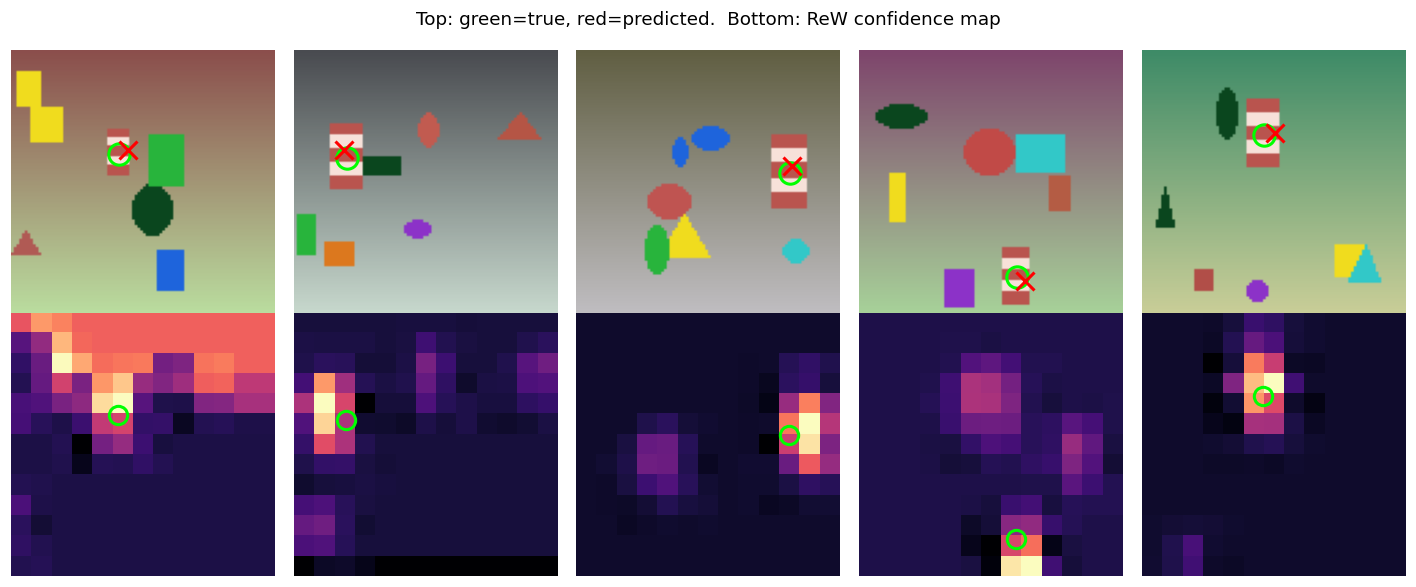

In [6]:
fig, ax = plt.subplots(2, 5, figsize=(13, 5.4))
rng = np.random.default_rng(20)
for j in range(5):
    img, (cx, cy) = make_scene(rng)
    sc, pos = score_map(img); px, py = localize(img)
    ax[0, j].imshow(img)
    ax[0, j].plot(cx, cy, 'o', mfc='none', mec='lime', ms=14, mew=2)
    ax[0, j].plot(px, py, 'x', c='red', ms=12, mew=2); ax[0, j].axis('off')
    ax[1, j].imshow(sc, cmap='magma', extent=[0, SCENE, SCENE, 0])
    ax[1, j].plot(cx, cy, 'o', mfc='none', mec='lime', ms=12, mew=2); ax[1, j].axis('off')
ax[0, 0].set_ylabel('scene'); ax[1, 0].set_ylabel('ReW score')
plt.suptitle('Top: green=true, red=predicted.  Bottom: ReW confidence map'); plt.tight_layout(); plt.show()

## Does the tie hold as it gets *harder*? A robustness sweep

The level field above is on clean patches. Notebooks `00`/`03` expose difficulty knobs the localiser has
not used — **palette jitter, rotation, photometric shift, occlusion**, and **distractor confusability**
(redder clutter). We fold them into one **difficulty** axis (0 = clean → 1 = severe), **retrain both
models** on patches of that difficulty, and localise in scenes of that difficulty. The question your
intuition asks: under stress, does one *thrive*?

difficulty :  0.0  0.2  0.4  0.6  0.8  1.0
ReW mean px:   3.1   5.5   8.3  13.5  18.0  23.6   | RF mean px:   4.1   7.0  10.3  10.9  14.3  22.1


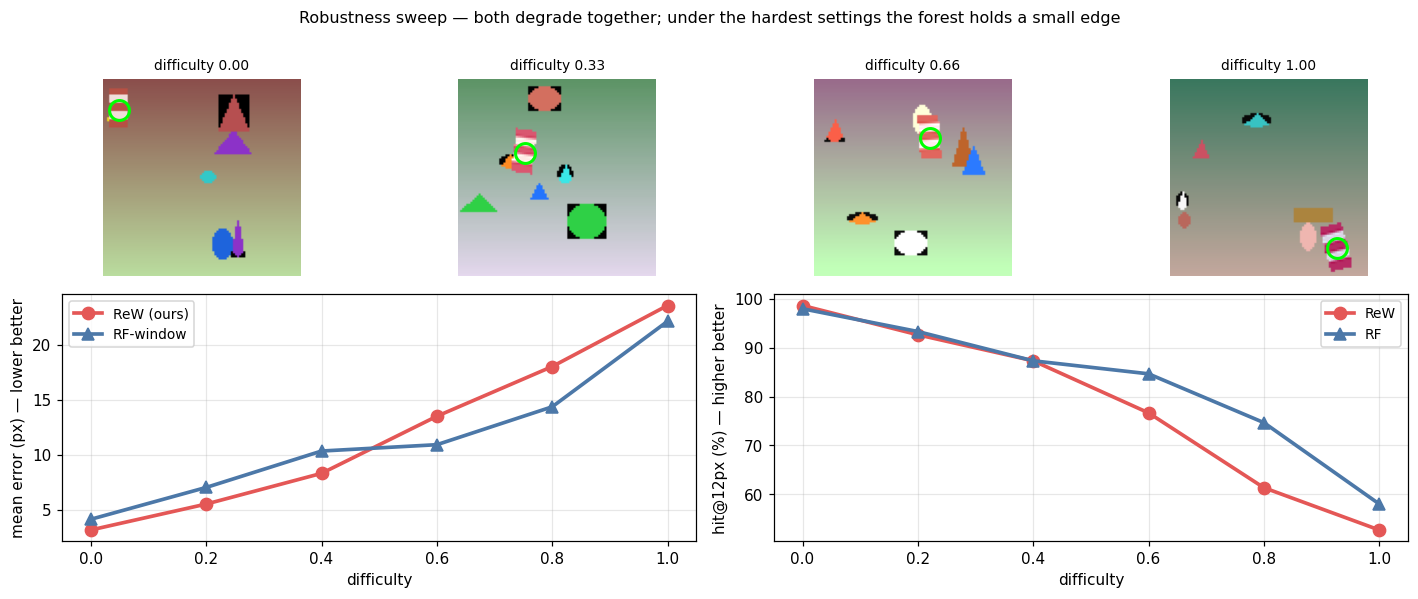

In [7]:
# crank all difficulty knobs together; retrain BOTH models at each level; localise at that level
def knobs_d(s):
    occ = 0.45*s; occ = 0.0 if occ < 0.2 else occ
    return dict(palette_jitter=int(10+40*s), rot=int(30*s), photometric=(0.6*s if s>0 else None), occlusion=occ)
def patch_d(cls, rng, s):
    k = knobs_d(s); rot = float(rng.integers(-k['rot'], k['rot']+1)) if k['rot'] else 0.0
    return C.render_patch(cls, WIN, rng, rotation=rot, palette_jitter=k['palette_jitter'],
                          photometric=k['photometric'], occlusion=k['occlusion'])[0]
def scene_d(rng, s):
    k = knobs_d(s); ov = 0.2 + 0.45*s
    bg = S.render_background(SCENE, 'gradient', rng).convert('RGBA')
    for _ in range(6):
        dw = int(rng.integers(6, 20)); dh = int(rng.integers(6, 20))
        bg.paste(S.render_distractor(dw, dh, rng, ov, k['palette_jitter']), (int(rng.integers(0, SCENE-dw)), int(rng.integers(0, SCENE-dh))), S.render_distractor(dw, dh, rng, ov, k['palette_jitter']))
    h = int(rng.integers(16, 28)); w = max(6, int(h*0.5)); rot = float(rng.integers(-k['rot'], k['rot']+1)) if k['rot'] else 0.0
    wal = S.render_target(w, h, n_stripes=5, rotation_deg=rot, rng=rng, palette_jitter=k['palette_jitter'])
    cw, ch = wal.size; x = int(rng.integers(0, SCENE-cw)); y = int(rng.integers(0, SCENE-ch)); bg.paste(wal, (x, y), wal)
    arr = np.asarray(bg.convert('RGB')).astype(np.float32)
    if k['photometric']:
        arr = np.clip(arr*(1+(rng.random()*2-1)*k['photometric']) + (rng.random()*2-1)*40*k['photometric'], 0, 255)
    return arr.astype(np.uint8), (x+cw/2, y+ch/2)

SEV = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]; rew_m, rf_m, rew_h, rf_h = [], [], [], []
for s in SEV:
    rng = np.random.default_rng(1); P_ = [patch_d('waldo', rng, s) for _ in range(500)]; N_ = []
    for cl in ['background', 'odlaw', 'wenda', 'wizard', 'woof']:
        for _ in range(150): N_.append(patch_d(cl, rng, s))
    Xs = P_ + N_; ys = np.r_[np.ones(len(P_)), np.zeros(len(N_))]
    ds = wp.DataSet()
    for b, l in zip(cs(Xs, 24), ys): ds.add(b.tolist(), float(l))
    rw = wp.RegressionWisard(12); rw.setMeanFunc(wp.GeometricMean()); rw.train(ds)
    rf = RandomForestClassifier(n_estimators=100, max_depth=12, n_jobs=-1, random_state=0).fit(csflat(Xs, 16), ys)
    wcl = list(rf.classes_).index(1.0)
    rng = np.random.default_rng(7); sc_test = [scene_d(rng, s) for _ in range(150)]; g = np.array([c for _, c in sc_test])
    def ev(fn): e = [WIN_COORDS[int(np.argmax(fn(win_imgs(im))))] for im, _ in sc_test]; return np.sqrt(((np.array(e)-g)**2).sum(1))
    def rwp(ws):
        q = wp.DataSet()
        for b in cs(ws, 24): q.add(b.tolist(), 0.0)
        return np.array(rw.predict(q))
    er = ev(rwp); ef = ev(lambda ws: rf.predict_proba(csflat(ws, 16))[:, wcl])
    rew_m.append(er.mean()); rf_m.append(ef.mean()); rew_h.append(100*(er<12).mean()); rf_h.append(100*(ef<12).mean())
print('difficulty :  ' + '  '.join('%.1f' % s for s in SEV))
print('ReW mean px:  ' + '  '.join('%4.1f' % v for v in rew_m) + '   | RF mean px:  ' + '  '.join('%4.1f' % v for v in rf_m))

fig = plt.figure(figsize=(13, 5.4)); gs = fig.add_gridspec(2, 4, height_ratios=[1, 1.25])
for j, s in enumerate([0.0, 0.33, 0.66, 1.0]):
    ax = fig.add_subplot(gs[0, j]); im, c = scene_d(np.random.default_rng(20+j), s)
    ax.imshow(im); ax.plot(*c, 'o', mfc='none', mec='lime', ms=13, mew=2); ax.set_title('difficulty %.2f' % s, fontsize=9); ax.axis('off')
a1 = fig.add_subplot(gs[1, :2]); a2 = fig.add_subplot(gs[1, 2:])
a1.plot(SEV, rew_m, '-o', color='#E45756', lw=2.4, ms=8, label='ReW (ours)'); a1.plot(SEV, rf_m, '-^', color='#4C78A8', lw=2.4, ms=8, label='RF-window')
a1.set_xlabel('difficulty'); a1.set_ylabel('mean error (px) — lower better'); a1.legend(fontsize=9); a1.grid(alpha=0.3)
a2.plot(SEV, rew_h, '-o', color='#E45756', lw=2.4, ms=8, label='ReW'); a2.plot(SEV, rf_h, '-^', color='#4C78A8', lw=2.4, ms=8, label='RF')
a2.set_xlabel('difficulty'); a2.set_ylabel('hit@12px (%) — higher better'); a2.legend(fontsize=9); a2.grid(alpha=0.3)
plt.suptitle('Robustness sweep — both degrade together; under the hardest settings the forest holds a small edge', y=1.0, fontsize=10.5)
plt.tight_layout(); plt.show()

**Reading the sweep.** Up to **moderate** difficulty the two are interchangeable; under the **hardest**
settings (heavy recolour + rotation + photometric shift + occlusion + red clutter) the **forest degrades
more gracefully** — a few-pixel, ~10-point-hit@12 edge — while ReW falls off a little faster. Crucially
*neither collapses* (both still localise the majority of scenes at difficulty 1.0). So the difficulty axis
does not hand the weightless net a win either: the honest verdict holds — **competitive, with RF the
marginally more robust learner** (the same ordering as notebook `02`'s static benchmark). The localiser's
value is its **novelty** and the weightless profile, not superior accuracy or robustness — the decisive
WiSARD advantage remains notebook `03`'s exact unlearning.

## Which binary encoder should the WiSARD read? Thermometer vs `colormask+stripe`

Everything so far fed the RAMs one encoding — `colormask+stripe`. But a weightless net
*cannot* read floats: the binary encoding is a **mandatory, first-class design choice**
(RF and the SVM never face it — they eat raw pixels / HOG). So it's worth asking the
WiSARD-internal question directly: **which encoding, and does difficulty change the answer?**
Four candidates, all at the *same* `canon16` resolution so only the encoding differs:

| encoder | bits/px | what each pixel becomes | nature |
|---|---|---|---|
| `therm8` | 24 | 8 thermometer bits per RGB channel | **dense** — full colour, the WNN default |
| `therm4` | 12 | 4 thermometer bits per channel | dense, coarser |
| `colormask` | 3 | `is_red` / `is_white` / `is_dark` | **categorical** — colour *abstracted* |
| `colormask+stripe` | 4 | colormask **+** the column-RLE stripe bit | categorical **+ structure** |

The intuition cuts two ways. *More bits = more information* says the thermometer should win.
*Categorical = noise-robust* says the masks should win once photometric jitter sets in. The
sweep settles it.

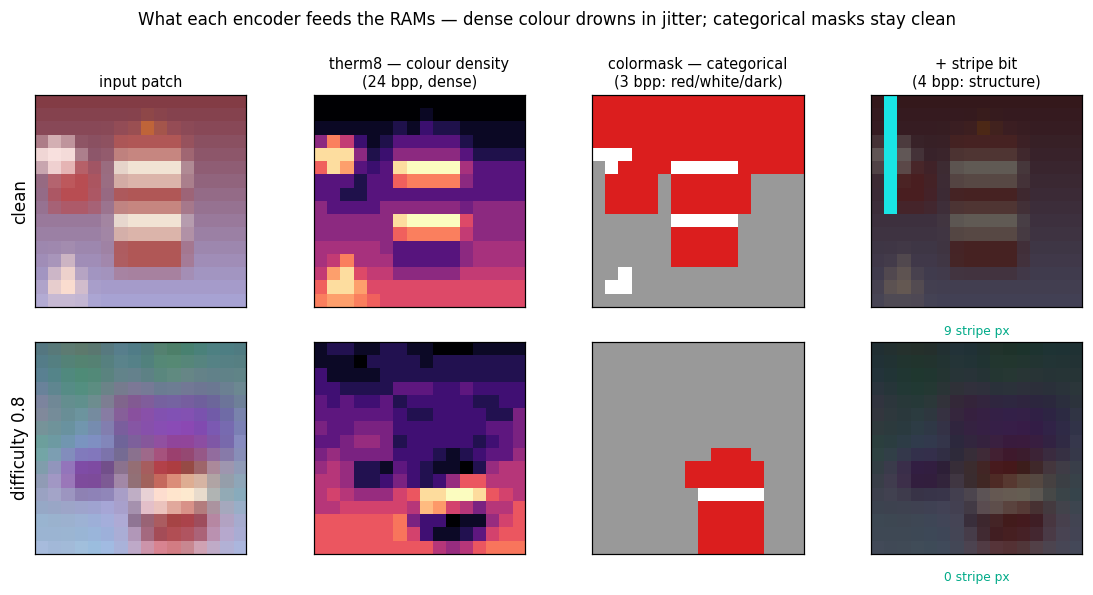

In [8]:
# ENCODER ANATOMY — what each candidate feeds the RAMs, clean vs hard
ENC_CANON = 16
def _planes(name, img): return bench.ENCODERS[name](bench.to_canon(img[None], ENC_CANON))[0].reshape(ENC_CANON, ENC_CANON, -1)
def _composite(csp):                                       # categorical reconstruction
    out = np.full((ENC_CANON, ENC_CANON, 3), 0.6)         # gray = none-of-the-above
    out[csp[..., 0] > 0] = [0.86, 0.12, 0.12]; out[csp[..., 1] > 0] = [1, 1, 1]; out[csp[..., 2] > 0] = [0, 0, 0]
    return out
rng = np.random.default_rng(3)
clean = patch_d('waldo', rng, 0.0); hard = patch_d('waldo', rng, 0.8)
fig, ax = plt.subplots(2, 4, figsize=(10.5, 5.3))
titles = ['input patch', 'therm8 — colour density\n(24 bpp, dense)',
          'colormask — categorical\n(3 bpp: red/white/dark)', '+ stripe bit\n(4 bpp: structure)']
for r, (img, lab) in enumerate([(clean, 'clean'), (hard, 'difficulty 0.8')]):
    base = bench.to_canon(img[None], ENC_CANON)[0]
    t8 = _planes('therm8', img).reshape(ENC_CANON, ENC_CANON, 3, 8).sum(3).sum(2)
    csp = _planes('colormask+stripe', img)
    ax[r, 0].imshow(base); ax[r, 0].set_ylabel(lab, fontsize=11)
    ax[r, 1].imshow(t8, cmap='magma'); ax[r, 2].imshow(_composite(csp))
    over = base.astype(float)/255*0.4; st = csp[..., 3] > 0; over[st] = [0.1, 0.9, 0.9]
    ax[r, 3].imshow(over)
    ax[r, 3].text(0.5, -0.13, f'{int(st.sum())} stripe px', transform=ax[r, 3].transAxes, ha='center', fontsize=8, color='#0a8')
    for c in range(4):
        ax[r, c].set_xticks([]); ax[r, c].set_yticks([])
        if r == 0: ax[r, c].set_title(titles[c], fontsize=9.5)
plt.suptitle('What each encoder feeds the RAMs — dense colour drowns in jitter; categorical masks stay clean', y=1.0, fontsize=11)
plt.tight_layout(); plt.show()

difficulty        :  0.0  0.2  0.4  0.6  0.8  1.0
therm8             24 bpp  12.1  16.4  19.0  30.5  30.3  38.9 px
therm4             12 bpp  10.9  16.5  22.7  31.2  33.4  35.9 px
colormask           3 bpp   8.4   8.8  16.7  17.5  26.2  30.7 px
colormask+stripe    4 bpp   4.5   7.5  10.5  11.5  15.5  28.8 px


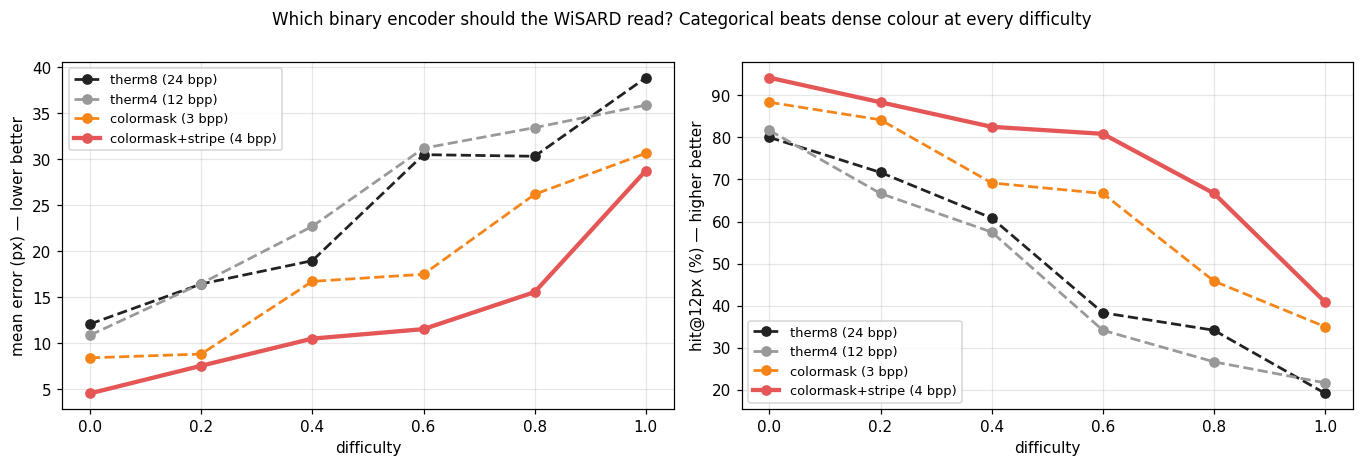

In [9]:
# ENCODER × DIFFICULTY — retrain a ReW localiser per encoder at each severity (same canon16, geom readout)
ENCS = [('therm8', '#222', '24 bpp'), ('therm4', '#999', '12 bpp'),
        ('colormask', '#F58518', '3 bpp'), ('colormask+stripe', '#E45756', '4 bpp')]
def _enc(name, ims): return bench.ENCODERS[name](bench.to_canon(np.stack(ims), ENC_CANON))
M = {e: [] for e, _, _ in ENCS}; Hh = {e: [] for e, _, _ in ENCS}
for s in SEV:
    rng = np.random.default_rng(1); P_ = [patch_d('waldo', rng, s) for _ in range(500)]; N_ = []
    for cl in ['background', 'odlaw', 'wenda', 'wizard', 'woof']:
        for _ in range(150): N_.append(patch_d(cl, rng, s))
    Xs = P_ + N_; ys = np.r_[np.ones(len(P_)), np.zeros(len(N_))]
    rng = np.random.default_rng(7); sc_test = [scene_d(rng, s) for _ in range(120)]; g = np.array([c for _, c in sc_test])
    for e, _, _ in ENCS:
        ds = wp.DataSet()
        for b, l in zip(_enc(e, Xs), ys): ds.add(b.tolist(), float(l))
        rw = wp.RegressionWisard(12); rw.setMeanFunc(wp.GeometricMean()); rw.train(ds)
        errs = []
        for im, _ in sc_test:
            q = wp.DataSet()
            for b in _enc(e, win_imgs(im)): q.add(b.tolist(), 0.0)
            errs.append(WIN_COORDS[int(np.argmax(np.array(rw.predict(q))))])
        er = np.sqrt(((np.array(errs) - g)**2).sum(1)); M[e].append(er.mean()); Hh[e].append(100*(er < 12).mean())
print('difficulty        :  ' + '  '.join('%.1f' % s for s in SEV))
for e, _, b in ENCS: print('%-18s %6s ' % (e, b) + ' '.join('%5.1f' % v for v in M[e]) + ' px')

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
for e, col, b in ENCS:
    ls = '-' if e == 'colormask+stripe' else '--'; lw = 2.8 if e == 'colormask+stripe' else 1.8
    ax[0].plot(SEV, M[e], ls, color=col, lw=lw, marker='o', ms=6, label=f'{e} ({b})')
    ax[1].plot(SEV, Hh[e], ls, color=col, lw=lw, marker='o', ms=6, label=f'{e} ({b})')
ax[0].set_ylabel('mean error (px) — lower better'); ax[1].set_ylabel('hit@12px (%) — higher better')
for a in ax: a.set_xlabel('difficulty'); a.grid(alpha=0.3); a.legend(fontsize=8.5)
plt.suptitle('Which binary encoder should the WiSARD read? Categorical beats dense colour at every difficulty', y=1.0, fontsize=11)
plt.tight_layout(); plt.show()

**Reading the encoder sweep.** The intuition that *more bits help* is **wrong here** — the
two dense thermometers (24 and 12 bpp) are the **worst** localisers at every difficulty and are
nearly indistinguishable from each other: full RGB hands the random RAM-mapping the background
gradient and every distractor's colour, and photometric jitter floods all 24 levels at once (see
the right-hand panels of the anatomy figure — `therm8` becomes pure noise by difficulty 0.8). The
**categorical** `colormask` (a mere 3 bpp) abstracts colour to *red / white / dark* and is far
more robust; adding the **stripe bit** (4 bpp) wins **at every severity**, and its margin is
*widest* in the moderate-difficulty band where structure still survives but colour alone starts to
confuse. Two honest caveats: the stripe bit is the **first casualty of rotation** (it drops to 0
px in the hard patch above), so `+stripe` decays toward plain `colormask` at the extreme; and by
difficulty 1.0 the scene is barely solvable, so all four converge. The takeaway is the
WiSARD-specific lesson: for a weightless net the **encoding is the model** — and the right move is
*fewer, well-chosen categorical bits*, not a denser thermometer. This is why `colormask+stripe` is
the default everywhere above — chosen on merit, not to flatter the comparison.

### Seeing the two levers under the hood

Two design choices take ReW from its 8px baseline to parity with the forest; these figures show *what they do*.

- **Hi-res encode (canon16 → canon24).** ReW doesn't read pixels — it reads the `colormask+stripe`
  **binary planes**. Imaging those planes for the same Waldo at each resolution shows the 24² grid
  resolving the red/white stripe bands that the 16² grid smears together — sharper patterns for the RAMs
  to memorise. (The `is_dark` plane is empty for Waldo, who is pure red+white; it lights up for the
  dark-hatted confusers.)
- **Geometric-mean readout.** ReW aggregates each window's RAM responses into one score. The arithmetic
  mean *averages* them (a few strongly-firing RAMs can carry a partial match); the **geometric** mean is
  **"AND-like"** — a single low-voting RAM drags the product down — so background and partial matches fade
  and the true peak sharpens. We see it directly in the score map.

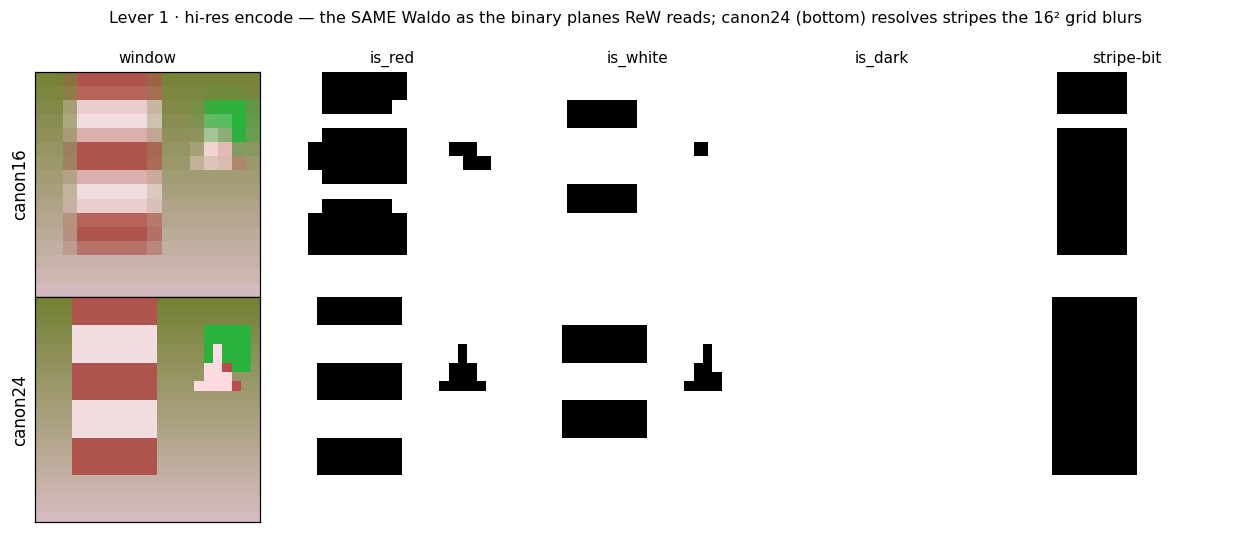

In [10]:
# LEVER 1 — the binary planes the RAMs actually read, at canon16 vs canon24
rng = np.random.default_rng(5); wal, _ = C.render_patch('waldo', WIN, rng, **C.PRESETS['clean'])
plane_names = ['is_red', 'is_white', 'is_dark', 'stripe-bit']
fig, ax = plt.subplots(2, 5, figsize=(11.5, 4.8))
for r, s in enumerate([16, 24]):
    ax[r, 0].imshow(bench.to_canon(wal[None], s)[0]); ax[r, 0].set_ylabel(f'canon{s}', fontsize=11)
    ax[r, 0].set_xticks([]); ax[r, 0].set_yticks([])
    planes = D.slim_encoder(bench.to_canon(wal[None], s)[0])
    for k in range(4):
        ax[r, k+1].imshow(planes[..., k], cmap='gray_r', vmin=0, vmax=1, interpolation='nearest'); ax[r, k+1].axis('off')
        if r == 0: ax[r, k+1].set_title(plane_names[k], fontsize=10)
ax[0, 0].set_title('window', fontsize=10)
plt.suptitle('Lever 1 · hi-res encode — the SAME Waldo as the binary planes ReW reads; canon24 (bottom) resolves stripes the 16² grid blurs', y=1.0, fontsize=10.5)
plt.tight_layout(); plt.show()

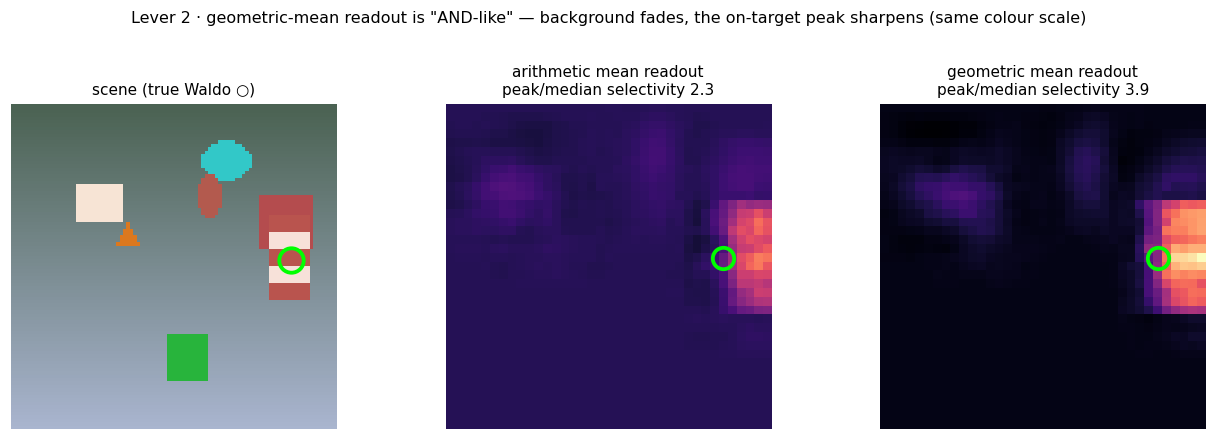

selectivity (peak/median): arithmetic 2.3  →  geometric 3.9   (sharper = better-localised peak)


In [11]:
# LEVER 2 — arithmetic vs geometric readout, same canon24 model, on a clean scene
r_arith = build_rew(24, 12); r_geom = build_rew(24, 12, wp.GeometricMean())
SR = 2; POSr = list(range(0, SCENE - WIN + 1, SR))
def score_grid(r, img):
    ims = [img[yy:yy+WIN, xx:xx+WIN] for yy in POSr for xx in POSr]
    q = wp.DataSet()
    for b in enc_cs(ims, 24): q.add(b.tolist(), 0.0)
    return np.array(r.predict(q)).reshape(len(POSr), len(POSr))
img, (cx, cy) = make_scene(np.random.default_rng(38))
sa, sg = score_grid(r_arith, img), score_grid(r_geom, img)
sel = lambda s: s.max() / (np.median(s) + 1e-6)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.8)); ext = [0, SCENE, SCENE, 0]
ax[0].imshow(img); ax[0].plot(cx, cy, 'o', mfc='none', mec='lime', ms=16, mew=2.5)
ax[0].set_title('scene (true Waldo ○)', fontsize=10); ax[0].axis('off')
vmin, vmax = min(sa.min(), sg.min()), max(sa.max(), sg.max())
for a, s, t in [(ax[1], sa, 'arithmetic mean'), (ax[2], sg, 'geometric mean')]:
    a.imshow(s, cmap='magma', extent=ext, vmin=vmin, vmax=vmax)
    a.plot(cx, cy, 'o', mfc='none', mec='lime', ms=14, mew=2.5); a.axis('off')
    a.set_title(f'{t} readout\npeak/median selectivity {sel(s):.1f}', fontsize=10)
plt.suptitle('Lever 2 · geometric-mean readout is "AND-like" — background fades, the on-target peak sharpens (same colour scale)', y=1.04, fontsize=10.5)
plt.tight_layout(); plt.show()
print('selectivity (peak/median): arithmetic %.1f  →  geometric %.1f   (sharper = better-localised peak)' % (sel(sa), sel(sg)))

## What does each localiser actually *look at*?

Metrics say *who* wins; they don't say *how*. We probe every scorer with one model-agnostic test —
**occlusion sensitivity**: take well-centred Waldo windows, slide a small grey patch across each, and
measure how far the model's *"Waldo-here"* score drops. The result is a map of **where the model looks
to decide**. This is the cross-model analogue of WiSARD's mental image in notebook `03`: a peek under
the hood, on equal footing, for a regression-WiSARD, a random forest, an SVM, and a template.

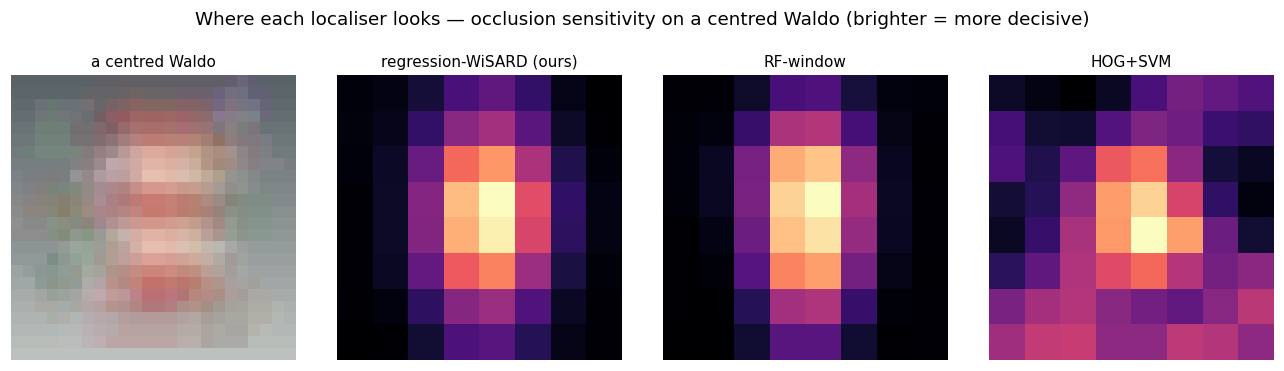

In [12]:
# occlusion-sensitivity maps: how much does covering each region drop the 'Waldo' score?
rng = np.random.default_rng(123)
refs = [C.render_patch('waldo', WIN, rng, **C.PRESETS['clean'])[0] for _ in range(15)]
def occ_map(score, osz=6, ostr=3):
    posns = [(yy, xx) for yy in range(0, WIN-osz+1, ostr) for xx in range(0, WIN-osz+1, ostr)]
    batch = list(refs)
    for (yy, xx) in posns:
        for im in refs:
            occ = im.copy(); occ[yy:yy+osz, xx:xx+osz] = 127; batch.append(occ)
    sc = score(batch); R = len(refs); base = sc[:R]
    acc = np.zeros((WIN, WIN)); cnt = np.zeros((WIN, WIN)); k = R
    for (yy, xx) in posns:
        acc[yy:yy+osz, xx:xx+osz] += (base - sc[k:k+R]).mean(); cnt[yy:yy+osz, xx:xx+osz] += 1; k += R
    return acc / np.maximum(cnt, 1)
maps = [('regression-WiSARD (ours)', sc_rew), ('RF-window', sc_rf), ('HOG+SVM', sc_svm)]
fig, ax = plt.subplots(1, 4, figsize=(12, 3.2))
ax[0].imshow(np.mean(refs, 0).astype(np.uint8)); ax[0].set_title('a centred Waldo', fontsize=10); ax[0].axis('off')
for a, (name, fn) in zip(ax[1:], maps):
    m = occ_map(fn); a.imshow(m, cmap='magma'); a.set_title(name, fontsize=10); a.axis('off')
plt.suptitle("Where each localiser looks — occlusion sensitivity on a centred Waldo (brighter = more decisive)", y=1.04)
plt.tight_layout(); plt.show()

## Takeaways
- A naive **global** ReW can't localise (it collapses to the mean position) — position is a *where*, not a
  global *what*. An honest negative worth reporting.
- A **sliding-window ReW confidence map** localises well and is a genuine, **novel weightless-native** use
  of Regression WiSARD — the contribution of this notebook.
- **On a level field** (both scorers given the same `colormask+stripe` planes, scored multi-axis), ReW and
  the tuned random forest **tie**: comparable error (~4px, RF a hair ahead at high capacity), ReW **on** the
  forest's accuracy×memory frontier (neither dominates), comparable inference. HOG+SVM trails both. The
  honest claim is **competitive, not a win** — consistent with the rest of the paper (`02`: RF keeps the
  static-accuracy crown).
- **Where the bespoke encoder mattered:** `colormask+stripe` lifts *both* models (RF on raw pixels ~5px →
  ~4px with the encoder), so it is reported as shared preprocessing, not a WiSARD-only advantage.
- **Under the hood**, occlusion sensitivity shows ReW and RF both lock onto Waldo's central stripes; the
  geometric-mean readout sharpens ReW's score map (an AND-like aggregation) — *how* it reaches parity.
- **The real WiSARD advantage is elsewhere**: notebook `03` shows exact, instant, leak-free *unlearning*,
  a deployment capability the forest cannot offer at any size. The localiser is a novelty result; the
  unlearning substrate is the headline.
- Exploration threads: multi-scale windows; planted near-Waldo confusers; sub-window offset regression for
  finer centres; whether ReW's incremental (single-pass, add-only) training helps in a streaming-deploy setting.